<a href="https://colab.research.google.com/github/Mohammed-Abu-Oudah/Car-Insurance-Classifier/blob/main/Car_insurance_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [46]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, accuracy_score, precision_score, recall_score
from google.colab import drive

In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
fpath = '/content/drive/MyDrive/AXSOSACADEMY/AXSOSACADEMY/05-IntermediateML/Week18/Data/Car_Insurance_Claim.csv'
df = pd.read_csv(fpath)
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   10000 non-null  int64  
 1   AGE                  10000 non-null  object 
 2   GENDER               10000 non-null  object 
 3   RACE                 10000 non-null  object 
 4   DRIVING_EXPERIENCE   10000 non-null  object 
 5   EDUCATION            10000 non-null  object 
 6   INCOME               10000 non-null  object 
 7   CREDIT_SCORE         9018 non-null   float64
 8   VEHICLE_OWNERSHIP    10000 non-null  float64
 9   VEHICLE_YEAR         10000 non-null  object 
 10  MARRIED              10000 non-null  float64
 11  CHILDREN             10000 non-null  float64
 12  POSTAL_CODE          10000 non-null  int64  
 13  ANNUAL_MILEAGE       9043 non-null   float64
 14  VEHICLE_TYPE         10000 non-null  object 
 15  SPEEDING_VIOLATIONS  10000 non-null  

,ID,AGE,GENDER,RACE,DRIVING_EXPERIENCE,EDUCATION,INCOME,CREDIT_SCORE,VEHICLE_OWNERSHIP,VEHICLE_YEAR,MARRIED,CHILDREN,POSTAL_CODE,ANNUAL_MILEAGE,VEHICLE_TYPE,SPEEDING_VIOLATIONS,DUIS,PAST_ACCIDENTS,OUTCOME
0,569520,65+,female,majority,0-9y,high school,upper class,0.629027,1.0,after 2015,0.0,1.0,10238,12000.0,sedan,0,0,0,0.0
1,750365,16-25,male,majority,0-9y,none,poverty,0.357757,0.0,before 2015,0.0,0.0,10238,16000.0,sedan,0,0,0,1.0
2,199901,16-25,female,majority,0-9y,high school,working class,0.493146,1.0,before 2015,0.0,0.0,10238,11000.0,sedan,0,0,0,0.0
3,478866,16-25,male,majority,0-9y,university,working class,0.206013,1.0,before 2015,0.0,1.0,32765,11000.0,sedan,0,0,0,0.0
4,731664,26-39,male,majority,10-19y,none,working class,0.388366,1.0,before 2015,0.0,0.0,32765,12000.0,sedan,2,0,1,1.0


We notice missing data in the CREDIT_SCORE column and ANNUAL_MILEAGE.

# Now let's explore the data

In [4]:
# First, ID doesn't add any value to the data, so it will be dropped
df = df.drop(columns='ID')
df.head()

,AGE,GENDER,RACE,DRIVING_EXPERIENCE,EDUCATION,INCOME,CREDIT_SCORE,VEHICLE_OWNERSHIP,VEHICLE_YEAR,MARRIED,CHILDREN,POSTAL_CODE,ANNUAL_MILEAGE,VEHICLE_TYPE,SPEEDING_VIOLATIONS,DUIS,PAST_ACCIDENTS,OUTCOME
0,65+,female,majority,0-9y,high school,upper class,0.629027,1.0,after 2015,0.0,1.0,10238,12000.0,sedan,0,0,0,0.0
1,16-25,male,majority,0-9y,none,poverty,0.357757,0.0,before 2015,0.0,0.0,10238,16000.0,sedan,0,0,0,1.0
2,16-25,female,majority,0-9y,high school,working class,0.493146,1.0,before 2015,0.0,0.0,10238,11000.0,sedan,0,0,0,0.0
3,16-25,male,majority,0-9y,university,working class,0.206013,1.0,before 2015,0.0,1.0,32765,11000.0,sedan,0,0,0,0.0
4,26-39,male,majority,10-19y,none,working class,0.388366,1.0,before 2015,0.0,0.0,32765,12000.0,sedan,2,0,1,1.0


In [6]:
# Let's take a look at the age
df['AGE'].value_counts()

,count
AGE,
26-39,3063
40-64,2931
16-25,2016
65+,1990


In [7]:
# Let's classify the AGE into more meaningful data, we will match these AGE data as the following:
# 16-25: Youth
# 26-39: Mature
# 40-64: Senior
# 65+: Old
replace_dict = {
    '16-25': 'Youth',
    '26-39': 'Mature',
    '40-64': 'Senior',
    '65+': 'Old'
}
df['AGE'] = df['AGE'].replace(replace_dict)
df['AGE'].value_counts()

,count
AGE,
Mature,3063
Senior,2931
Youth,2016
Old,1990


In [8]:
df.head()

,AGE,GENDER,RACE,DRIVING_EXPERIENCE,EDUCATION,INCOME,CREDIT_SCORE,VEHICLE_OWNERSHIP,VEHICLE_YEAR,MARRIED,CHILDREN,POSTAL_CODE,ANNUAL_MILEAGE,VEHICLE_TYPE,SPEEDING_VIOLATIONS,DUIS,PAST_ACCIDENTS,OUTCOME
0,Old,female,majority,0-9y,high school,upper class,0.629027,1.0,after 2015,0.0,1.0,10238,12000.0,sedan,0,0,0,0.0
1,Youth,male,majority,0-9y,none,poverty,0.357757,0.0,before 2015,0.0,0.0,10238,16000.0,sedan,0,0,0,1.0
2,Youth,female,majority,0-9y,high school,working class,0.493146,1.0,before 2015,0.0,0.0,10238,11000.0,sedan,0,0,0,0.0
3,Youth,male,majority,0-9y,university,working class,0.206013,1.0,before 2015,0.0,1.0,32765,11000.0,sedan,0,0,0,0.0
4,Mature,male,majority,10-19y,none,working class,0.388366,1.0,before 2015,0.0,0.0,32765,12000.0,sedan,2,0,1,1.0


In [9]:
# GENDER male and female is verbose, let's make them m and f, and when encoding them we can drop first.
df['GENDER'].value_counts()

,count
GENDER,
female,5010
male,4990


In [11]:
replace_dict = {
    'male': 'm',
    'female': 'f'
}
df['GENDER'] = df['GENDER'].replace(replace_dict)
df['GENDER'].value_counts()

,count
GENDER,
f,5010
m,4990


In [12]:
# Let's take a look at the RACE column
df['RACE'].value_counts()

,count
RACE,
majority,9012
minority,988


In [13]:
# Now let's look at the driving experience
df['DRIVING_EXPERIENCE'].value_counts()

,count
DRIVING_EXPERIENCE,
0-9y,3530
10-19y,3299
20-29y,2119
30y+,1052


In [14]:
# I don't like how they look at the moment, let's match them like this:
# 0-9y: Normal
# 10-19y: High
# 20-29y: Senior
# 30y+: Expert
replace_dict = {
    '0-9y': 'Normal',
    '10-19y': 'High',
    '20-29y': 'Senior',
    '30y+': 'Expert'
}
df['DRIVING_EXPERIENCE'] = df['DRIVING_EXPERIENCE'].replace(replace_dict)
df['DRIVING_EXPERIENCE'].value_counts()

,count
DRIVING_EXPERIENCE,
Normal,3530
High,3299
Senior,2119
Expert,1052


In [15]:
# Let's take a look at Education column
df['EDUCATION'].value_counts()

,count
EDUCATION,
high school,4157
university,3928
none,1915


Ok, this is considered ordial and we can make them in the order.

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   AGE                  10000 non-null  object 
 1   GENDER               10000 non-null  object 
 2   RACE                 10000 non-null  object 
 3   DRIVING_EXPERIENCE   10000 non-null  object 
 4   EDUCATION            10000 non-null  object 
 5   INCOME               10000 non-null  object 
 6   CREDIT_SCORE         9018 non-null   float64
 7   VEHICLE_OWNERSHIP    10000 non-null  float64
 8   VEHICLE_YEAR         10000 non-null  object 
 9   MARRIED              10000 non-null  float64
 10  CHILDREN             10000 non-null  float64
 11  POSTAL_CODE          10000 non-null  int64  
 12  ANNUAL_MILEAGE       9043 non-null   float64
 13  VEHICLE_TYPE         10000 non-null  object 
 14  SPEEDING_VIOLATIONS  10000 non-null  int64  
 15  DUIS                 10000 non-null  

In [17]:
# let's check the income column
df['INCOME'].value_counts()

,count
INCOME,
upper class,4336
middle class,2138
poverty,1814
working class,1712


Ok, that is too considered an ordinal one.

In [18]:
df['CREDIT_SCORE'].describe()

,CREDIT_SCORE
count,9018.000000
mean,0.515813
std,0.137688
min,0.053358
25%,0.417191
50%,0.525033
75%,0.618312
max,0.960819


In [19]:
df.loc[df['CREDIT_SCORE'] > 0.7]

,AGE,GENDER,RACE,DRIVING_EXPERIENCE,EDUCATION,INCOME,CREDIT_SCORE,VEHICLE_OWNERSHIP,VEHICLE_YEAR,MARRIED,CHILDREN,POSTAL_CODE,ANNUAL_MILEAGE,VEHICLE_TYPE,SPEEDING_VIOLATIONS,DUIS,PAST_ACCIDENTS,OUTCOME
11,Old,f,majority,Expert,high school,upper class,0.729831,1.0,after 2015,1.0,0.0,32765,12000.0,sedan,4,0,0,0.0
15,Mature,f,majority,Normal,high school,upper class,0.762798,0.0,after 2015,1.0,0.0,10238,NaN,sedan,0,0,0,0.0
16,Old,m,majority,Expert,university,upper class,0.796175,1.0,before 2015,1.0,1.0,32765,NaN,sedan,10,2,1,0.0
31,Old,f,majority,Expert,university,upper class,0.701268,1.0,before 2015,1.0,1.0,10238,10000.0,sedan,3,1,1,0.0
40,Old,m,majority,Expert,high school,upper class,0.705454,1.0,before 2015,1.0,1.0,10238,10000.0,sedan,5,1,3,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9929,Old,f,majority,Expert,university,upper class,0.765637,1.0,before 2015,1.0,1.0,32765,6000.0,sedan,6,0,1,0.0
9949,Old,f,majority,High,university,upper class,0.782537,1.0,before 2015,1.0,1.0,10238,16000.0,sedan,0,0,1,0.0
9950,Senior,f,majority,Senior,university,upper class,0.700582,1.0,after 2015,1.0,1.0,32765,NaN,sedan,3,2,2,0.0
9977,Old,m,minority,Normal,none,upper class,0.710640,1.0,after 2015,0.0,1.0,32765,NaN,sedan,0,0,0,0.0


We will leave the credit score as it is at the moment.

In [20]:
# Let's take a look at the VEHICLE_OWNERSHIP column.
df['VEHICLE_OWNERSHIP'].describe()

,VEHICLE_OWNERSHIP
count,10000.000000
mean,0.697000
std,0.459578
min,0.000000
25%,0.000000
50%,1.000000
75%,1.000000
max,1.000000


In [21]:
df['VEHICLE_OWNERSHIP'].value_counts()

,count
VEHICLE_OWNERSHIP,
1.0,6970
0.0,3030


In [22]:
# Let's inspect the VEHICLE_YEAR column
df['VEHICLE_YEAR'].value_counts()

,count
VEHICLE_YEAR,
before 2015,6967
after 2015,3033


In [23]:
# I don't like its shap like this, I will do Old and New instead
# before 2015 => Old
# after 2015 => New
replace_dict = {
    'before 2015': 'Old',
    'after 2015': 'New'
}

df['VEHICLE_YEAR'] = df['VEHICLE_YEAR'].replace(replace_dict)
df['VEHICLE_YEAR'].value_counts()

,count
VEHICLE_YEAR,
Old,6967
New,3033


In [24]:
# Let's take a look at the MARRIED column.
df['MARRIED'].value_counts()

,count
MARRIED,
0.0,5018
1.0,4982


Married columns seems cool

In [25]:
# Let's look at the Childern columns
df['CHILDREN'].value_counts()

,count
CHILDREN,
1.0,6888
0.0,3112


it seems fine

Postal code column, doesn't add any value to the data, we will need to remove it.

In [27]:
df['POSTAL_CODE'].describe()

,POSTAL_CODE
count,10000.000000
mean,19864.548400
std,18915.613855
min,10238.000000
25%,10238.000000
50%,10238.000000
75%,32765.000000
max,92101.000000


In [28]:
df = df.drop(columns='POSTAL_CODE')
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   AGE                  10000 non-null  object 
 1   GENDER               10000 non-null  object 
 2   RACE                 10000 non-null  object 
 3   DRIVING_EXPERIENCE   10000 non-null  object 
 4   EDUCATION            10000 non-null  object 
 5   INCOME               10000 non-null  object 
 6   CREDIT_SCORE         9018 non-null   float64
 7   VEHICLE_OWNERSHIP    10000 non-null  float64
 8   VEHICLE_YEAR         10000 non-null  object 
 9   MARRIED              10000 non-null  float64
 10  CHILDREN             10000 non-null  float64
 11  ANNUAL_MILEAGE       9043 non-null   float64
 12  VEHICLE_TYPE         10000 non-null  object 
 13  SPEEDING_VIOLATIONS  10000 non-null  int64  
 14  DUIS                 10000 non-null  int64  
 15  PAST_ACCIDENTS       10000 non-null  

,AGE,GENDER,RACE,DRIVING_EXPERIENCE,EDUCATION,INCOME,CREDIT_SCORE,VEHICLE_OWNERSHIP,VEHICLE_YEAR,MARRIED,CHILDREN,ANNUAL_MILEAGE,VEHICLE_TYPE,SPEEDING_VIOLATIONS,DUIS,PAST_ACCIDENTS,OUTCOME
0,Old,f,majority,Normal,high school,upper class,0.629027,1.0,New,0.0,1.0,12000.0,sedan,0,0,0,0.0
1,Youth,m,majority,Normal,none,poverty,0.357757,0.0,Old,0.0,0.0,16000.0,sedan,0,0,0,1.0
2,Youth,f,majority,Normal,high school,working class,0.493146,1.0,Old,0.0,0.0,11000.0,sedan,0,0,0,0.0
3,Youth,m,majority,Normal,university,working class,0.206013,1.0,Old,0.0,1.0,11000.0,sedan,0,0,0,0.0
4,Mature,m,majority,High,none,working class,0.388366,1.0,Old,0.0,0.0,12000.0,sedan,2,0,1,1.0


In [29]:
# Let's have a look at the anuual Milage
df['ANNUAL_MILEAGE'].describe()

,ANNUAL_MILEAGE
count,9043.000000
mean,11697.003207
std,2818.434528
min,2000.000000
25%,10000.000000
50%,12000.000000
75%,14000.000000
max,22000.000000


Values seem so normal, we will move to the next.

In [30]:
# Let's take a look at the VEHICLE_TYPE column
df['VEHICLE_TYPE'].value_counts()

,count
VEHICLE_TYPE,
sedan,9523
sports car,477


This column is almost quasi-constant and will have to be removed, but let's first see what visual representation is telling us, if it doesn't add real effect it should be removed.

In [31]:
# Let's take a look at the SPEEDING_VIOLATIONS columns
df['SPEEDING_VIOLATIONS'].describe()

,SPEEDING_VIOLATIONS
count,10000.000000
mean,1.482900
std,2.241966
min,0.000000
25%,0.000000
50%,0.000000
75%,2.000000
max,22.000000


In [32]:
df['SPEEDING_VIOLATIONS'].value_counts()

,count
SPEEDING_VIOLATIONS,
0,5028
1,1544
2,1161
3,830
4,530
5,319
6,188
7,140
8,75


Things here look normal.

In [33]:
# Now let's look at the DUIS column
df['DUIS'].describe()

,DUIS
count,10000.00000
mean,0.23920
std,0.55499
min,0.00000
25%,0.00000
50%,0.00000
75%,0.00000
max,6.00000


In [34]:
df['DUIS'].value_counts()

,count
DUIS,
0,8118
1,1470
2,331
3,68
4,10
5,2
6,1


In [35]:
# Now let's see the past_accidents column
df['PAST_ACCIDENTS'].describe()

,PAST_ACCIDENTS
count,10000.000000
mean,1.056300
std,1.652454
min,0.000000
25%,0.000000
50%,0.000000
75%,2.000000
max,15.000000


In [36]:
df['PAST_ACCIDENTS'].value_counts()

,count
PAST_ACCIDENTS,
0,5584
1,1783
2,1104
3,646
4,366
5,232
6,144
7,61
8,41


In [37]:
# and finally let's look at the target outcome
df['OUTCOME'].value_counts()

,count
OUTCOME,
0.0,6867
1.0,3133


Things are now perfect, let's check for duplications and remove them before proceeding to visulization.

In [40]:
df.duplicated().sum()

np.int64(20)

In [41]:
df = df.drop_duplicates()

In [42]:
df.duplicated().sum()

np.int64(0)

In [43]:
# UNIVARIATE PLOTTING FUNCTIONS FOR EDA
def explore_categorical(df, x, fillna = True, placeholder = 'MISSING',
                        figsize = (6,4), order = None):
  """Creates a seaborn countplot with the option to temporarily fill missing values
  Prints statements about null values, cardinality, and checks for
  constant/quasi-constant features.
  Source:{PASTE IN FINAL LESSON LINK}
  """
  # Make a copy of the dataframe and fillna
  temp_df = df.copy()
  # Before filling nulls, save null value counts and percent for printing
  null_count = temp_df[x].isna().sum()
  null_perc = null_count/len(temp_df)* 100
  # fillna with placeholder
  if fillna == True:
    temp_df[x] = temp_df[x].fillna(placeholder)
  # Create figure with desired figsize
  fig, ax = plt.subplots(figsize=figsize)
  # Plotting a count plot
  sns.countplot(data=temp_df, x=x, ax=ax, order=order)
  # Rotate Tick Labels for long names
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
  # Add a title with the feature name included
  ax.set_title(f"Column: {x}", fontweight='bold')
  # Fix layout and show plot (before print statements)
  fig.tight_layout()
  plt.show()

  # Print null value info
  print(f"- NaN's Found: {null_count} ({round(null_perc,2)}%)")
  # Print cardinality info
  nunique = temp_df[x].nunique()
  print(f"- Unique Values: {nunique}")

  # First find value counts of feature
  val_counts = temp_df[x].value_counts(dropna=False)
  # Define the most common value
  most_common_val = val_counts.index[0]
  # Define the frequency of the most common value
  freq = val_counts.values[0]
  # Calculate the percentage of the most common value
  perc_most_common = freq / len(temp_df) * 100

  # Print the results
  print(f"- Most common value: '{most_common_val}' occurs {freq} times ({round(perc_most_common,2)}%)")
  # print message if quasi-constant or constant (most common val more than 98% of data)
  if perc_most_common > 98:
    print(f"\n- [!] Warning: '{x}' is a constant or quasi-constant feature and should be dropped.")
  else:
    print("- Not constant or quasi-constant.")
  return fig, ax

In [44]:
def explore_numeric(df, x, figsize=(6,5) ):
  """Creates a seaborn histplot and boxplot with a share x-axis,
  Prints statements about null values, cardinality, and checks for
  constant/quasi-constant features.
  Source:{PASTE IN FINAL LESSON LINK}
  """

  ## Save null value counts and percent for printing
  null_count = df[x].isna().sum()
  null_perc = null_count/len(df)* 100


  ## Making our figure with gridspec for subplots
  gridspec = {'height_ratios':[0.7,0.3]}
  fig, axes = plt.subplots(nrows=2, figsize=figsize,
                           sharex=True, gridspec_kw=gridspec)
  # Histogram on Top
  sns.histplot(data=df, x=x, ax=axes[0])

  # Boxplot on Bottom
  sns.boxplot(data=df, x=x, ax=axes[1])

  ## Adding a title
  axes[0].set_title(f"Column: {x}", fontweight='bold')

  ## Adjusting subplots to best fill Figure
  fig.tight_layout()

  # Ensure plot is shown before message
  plt.show()
  # Print null value info
  print(f"- NaN's Found: {null_count} ({round(null_perc,2)}%)")
  # Print cardinality info
  nunique = df[x].nunique()
  print(f"- Unique Values: {nunique}")


  # Get the most most common value, its count as # and as %
  most_common_val_count = df[x].value_counts(dropna=False).head(1)
  most_common_val = most_common_val_count.index[0]
  freq = most_common_val_count.values[0]
  perc_most_common = freq / len(df) * 100

  print(f"- Most common value: '{most_common_val}' occurs {freq} times ({round(perc_most_common,2)}%)")

  # print message if quasi-constant or constant (most common val more than 98% of data)
  if perc_most_common > 98:
    print(f"\n- [!] Warning: '{x}' is a constant or quasi-constant feature and should be dropped.")
  else:
    print("- Not constant or quasi-constant.")
  return fig, axes

In [49]:
def plot_categorical_vs_target(df, x, y='OUTCOME',figsize=(6,4),
                            fillna = True, placeholder = 'MISSING',
                            order = None):
  """Plots a combination of a seaborn barplot of means combined with
  a seaborn stripplot to show the spread of the data.
  Source:{PASTE IN FINAL LESSON LINK}
  """
  # Make a copy of the dataframe and fillna
  temp_df = df.copy()
  # fillna with placeholder
  if fillna == True:
    temp_df[x] = temp_df[x].fillna(placeholder)

  # or drop nulls prevent unwanted 'nan' group in stripplot
  else:
    temp_df = temp_df.dropna(subset=[x])
  # Create the figure and subplots
  fig, ax = plt.subplots(figsize=figsize)

    # Barplot
  sns.barplot(data=temp_df, x=x, y=y, ax=ax, order=order, alpha=0.6,
              linewidth=1, edgecolor='black', errorbar=None)

  # Boxplot
  sns.stripplot(data=temp_df, x=x, y=y, hue=x, ax=ax,
                order=order, hue_order=order, legend=False,
                edgecolor='white', linewidth=0.5,
                size=3,zorder=0)
  # Rotate xlabels
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

  # Add a title
  ax.set_title(f"{x} vs. {y}", fontweight='bold')
  fig.tight_layout()
  return fig, ax

In [50]:
def plot_numeric_vs_target(df, x, y='OUTCOME',
                           figsize=(6,4)):
  """Plots a seaborn regplot with Pearson's correlation (r) added
  to the title.
  Source:{PASTE IN FINAL LESSON LINK}
  """
  # Calculate the correlation
  corr = df[[x,y]].corr().round(2)
  r = corr.loc[x,y]

  # Plot the data
  fig, ax = plt.subplots(figsize=figsize)
  scatter_kws={'ec':'white','linewidths':1,'alpha':0.8}
  sns.regplot(data=df, x=x, y=y, ax=ax, scatter_kws=scatter_kws)

  ## Add the title with the correlation
  ax.set_title(f"{x} vs. {y} (r = {r})", fontweight='bold')

  # Make sure the plot is shown before the print statement
  plt.show()

  return fig, ax

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9980 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   AGE                  9980 non-null   object 
 1   GENDER               9980 non-null   object 
 2   RACE                 9980 non-null   object 
 3   DRIVING_EXPERIENCE   9980 non-null   object 
 4   EDUCATION            9980 non-null   object 
 5   INCOME               9980 non-null   object 
 6   CREDIT_SCORE         9018 non-null   float64
 7   VEHICLE_OWNERSHIP    9980 non-null   float64
 8   VEHICLE_YEAR         9980 non-null   object 
 9   MARRIED              9980 non-null   float64
 10  CHILDREN             9980 non-null   float64
 11  ANNUAL_MILEAGE       9028 non-null   float64
 12  VEHICLE_TYPE         9980 non-null   object 
 13  SPEEDING_VIOLATIONS  9980 non-null   int64  
 14  DUIS                 9980 non-null   int64  
 15  PAST_ACCIDENTS       9980 non-null   int64 

/tmp/ipykernel_9708/1926817873.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'VEHICLE_TYPE vs. OUTCOME'}, xlabel='VEHICLE_TYPE', ylabel='OUTCOME'>)

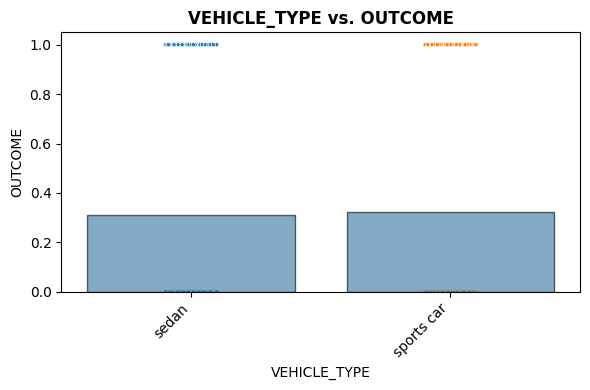

In [51]:
plot_categorical_vs_target(df, 'VEHICLE_TYPE')

We can notice that the average outcome for sports car is same as sedan so we will drop the vehical type column.

In [52]:
df = df.drop(columns='VEHICLE_TYPE')
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 9980 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   AGE                  9980 non-null   object 
 1   GENDER               9980 non-null   object 
 2   RACE                 9980 non-null   object 
 3   DRIVING_EXPERIENCE   9980 non-null   object 
 4   EDUCATION            9980 non-null   object 
 5   INCOME               9980 non-null   object 
 6   CREDIT_SCORE         9018 non-null   float64
 7   VEHICLE_OWNERSHIP    9980 non-null   float64
 8   VEHICLE_YEAR         9980 non-null   object 
 9   MARRIED              9980 non-null   float64
 10  CHILDREN             9980 non-null   float64
 11  ANNUAL_MILEAGE       9028 non-null   float64
 12  SPEEDING_VIOLATIONS  9980 non-null   int64  
 13  DUIS                 9980 non-null   int64  
 14  PAST_ACCIDENTS       9980 non-null   int64  
 15  OUTCOME              9980 non-null   float6

,AGE,GENDER,RACE,DRIVING_EXPERIENCE,EDUCATION,INCOME,CREDIT_SCORE,VEHICLE_OWNERSHIP,VEHICLE_YEAR,MARRIED,CHILDREN,ANNUAL_MILEAGE,SPEEDING_VIOLATIONS,DUIS,PAST_ACCIDENTS,OUTCOME
0,Old,f,majority,Normal,high school,upper class,0.629027,1.0,New,0.0,1.0,12000.0,0,0,0,0.0
1,Youth,m,majority,Normal,none,poverty,0.357757,0.0,Old,0.0,0.0,16000.0,0,0,0,1.0
2,Youth,f,majority,Normal,high school,working class,0.493146,1.0,Old,0.0,0.0,11000.0,0,0,0,0.0
3,Youth,m,majority,Normal,university,working class,0.206013,1.0,Old,0.0,1.0,11000.0,0,0,0,0.0
4,Mature,m,majority,High,none,working class,0.388366,1.0,Old,0.0,0.0,12000.0,2,0,1,1.0


Let's make sure that we fully understand the purpose of the DUIS column by plotting it against the target.

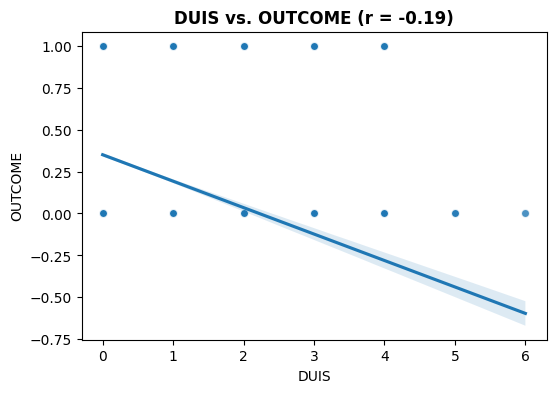

(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'DUIS vs. OUTCOME (r = -0.19)'}, xlabel='DUIS', ylabel='OUTCOME'>)

In [53]:
plot_numeric_vs_target(df, 'DUIS')

Ok now we are sure that the DUIS mean driving under the influence of drug or alchoholic which clearly affects the possiblity of someone receiving insurance.

In [54]:
numeric_cols = df.select_dtypes(include='number').columns
numeric_cols

Index(['CREDIT_SCORE', 'VEHICLE_OWNERSHIP', 'MARRIED', 'CHILDREN',
       'ANNUAL_MILEAGE', 'SPEEDING_VIOLATIONS', 'DUIS', 'PAST_ACCIDENTS',
       'OUTCOME'],
      dtype='object')

In [55]:
ordinal_cols = ['AGE', 'DRIVING_EXPERIENCE', 'EDUCATION', 'INCOME']
ordinal_cols

['AGE', 'DRIVING_EXPERIENCE', 'EDUCATION', 'INCOME']

In [57]:
cat_cols = df.select_dtypes(include='object').drop(columns=ordinal_cols).columns
cat_cols

Index(['GENDER', 'RACE', 'VEHICLE_YEAR'], dtype='object')

/tmp/ipykernel_9708/4216392884.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


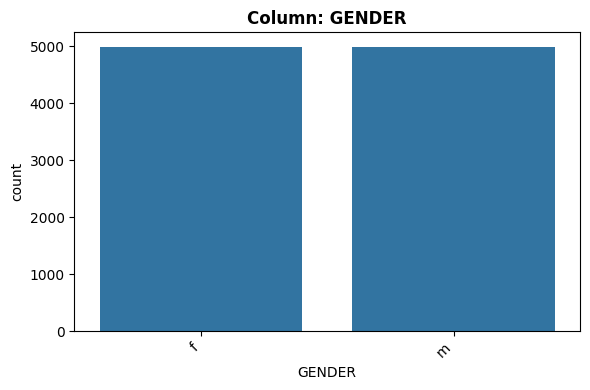

- NaN's Found: 0 (0.0%)
- Unique Values: 2
- Most common value: 'f' occurs 4998 times (50.08%)
- Not constant or quasi-constant.


/tmp/ipykernel_9708/4216392884.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


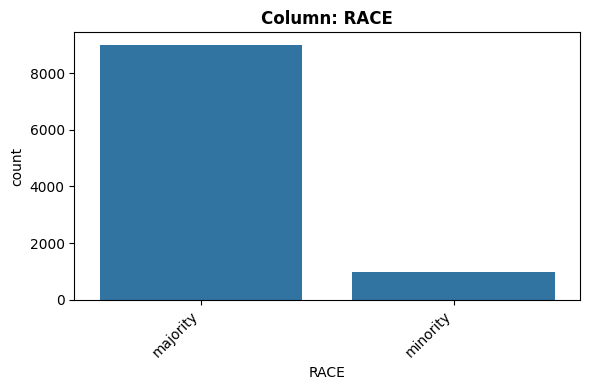

- NaN's Found: 0 (0.0%)
- Unique Values: 2
- Most common value: 'majority' occurs 8992 times (90.1%)
- Not constant or quasi-constant.


/tmp/ipykernel_9708/4216392884.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


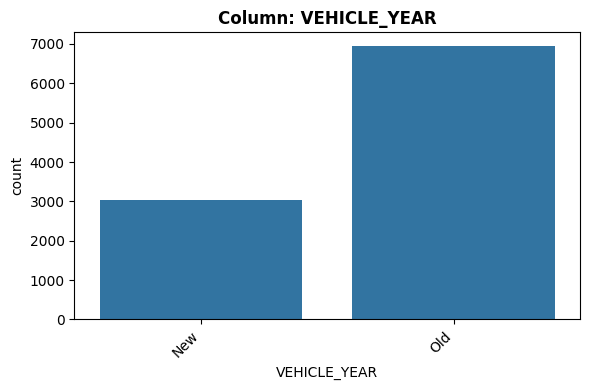

- NaN's Found: 0 (0.0%)
- Unique Values: 2
- Most common value: 'Old' occurs 6948 times (69.62%)
- Not constant or quasi-constant.


In [58]:
for col in cat_cols:
  explore_categorical(df, col)

/tmp/ipykernel_9708/4216392884.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


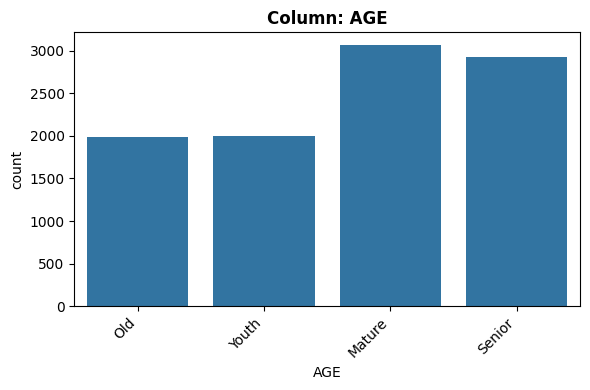

- NaN's Found: 0 (0.0%)
- Unique Values: 4
- Most common value: 'Mature' occurs 3061 times (30.67%)
- Not constant or quasi-constant.


/tmp/ipykernel_9708/4216392884.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


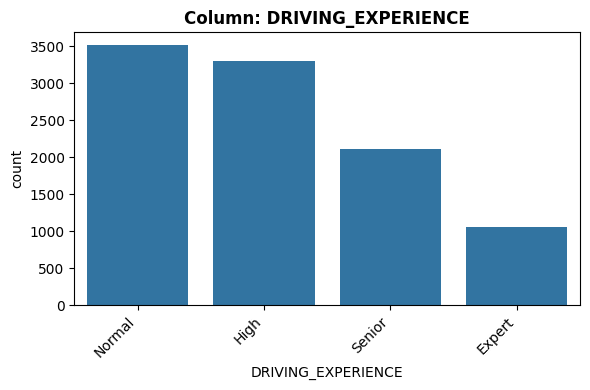

- NaN's Found: 0 (0.0%)
- Unique Values: 4
- Most common value: 'Normal' occurs 3513 times (35.2%)
- Not constant or quasi-constant.


/tmp/ipykernel_9708/4216392884.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


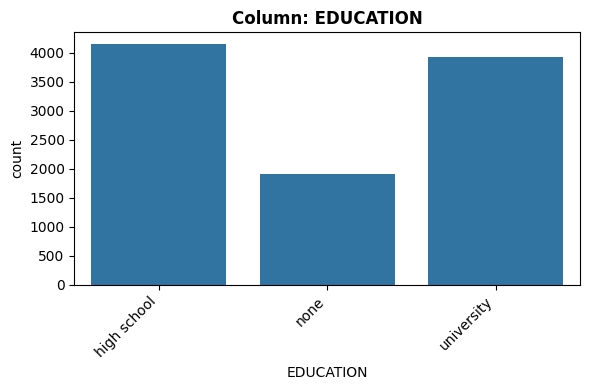

- NaN's Found: 0 (0.0%)
- Unique Values: 3
- Most common value: 'high school' occurs 4148 times (41.56%)
- Not constant or quasi-constant.


/tmp/ipykernel_9708/4216392884.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


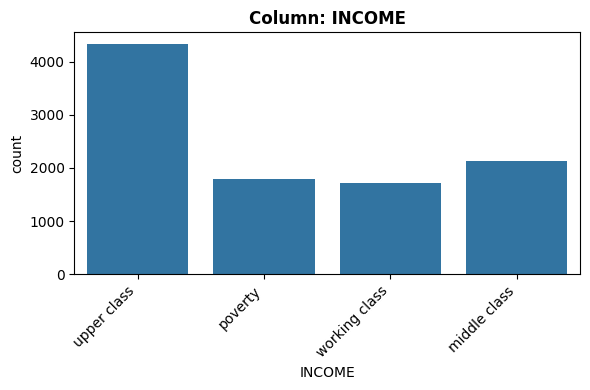

- NaN's Found: 0 (0.0%)
- Unique Values: 4
- Most common value: 'upper class' occurs 4334 times (43.43%)
- Not constant or quasi-constant.


In [59]:
for col in ordinal_cols:
  explore_categorical(df, col)

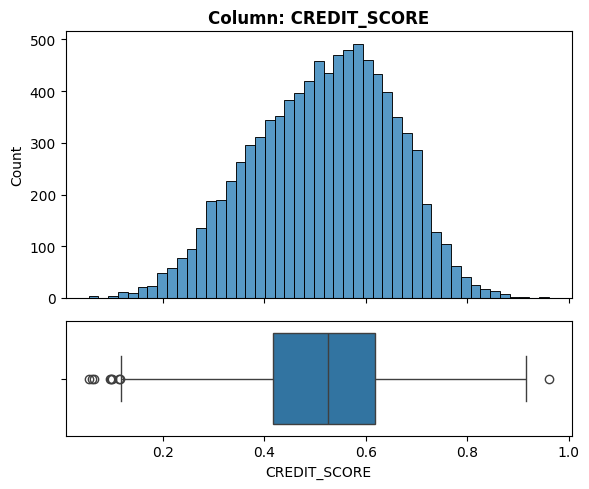

- NaN's Found: 962 (9.64%)
- Unique Values: 9018
- Most common value: 'nan' occurs 962 times (9.64%)
- Not constant or quasi-constant.


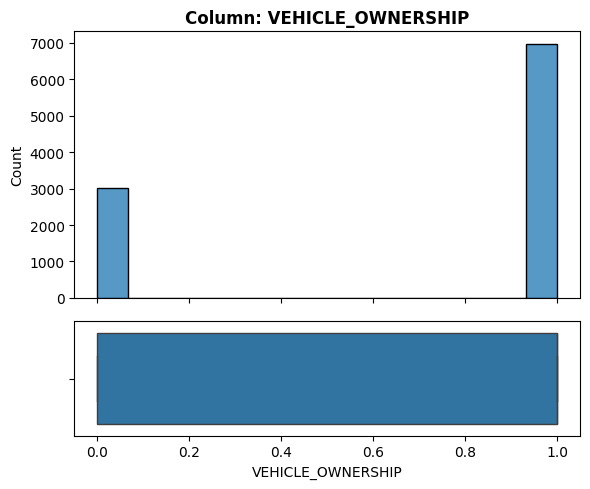

- NaN's Found: 0 (0.0%)
- Unique Values: 2
- Most common value: '1.0' occurs 6964 times (69.78%)
- Not constant or quasi-constant.


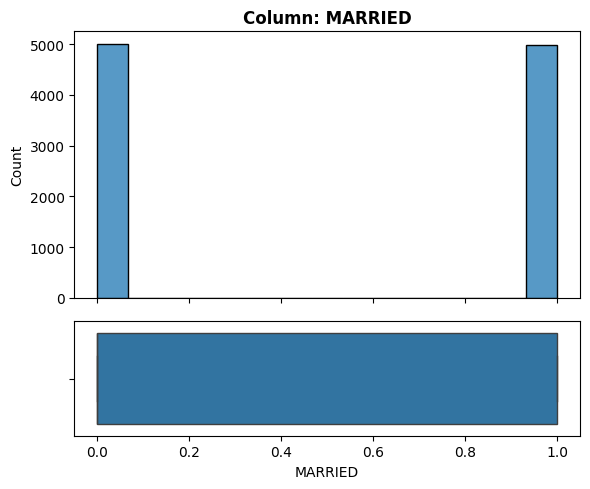

- NaN's Found: 0 (0.0%)
- Unique Values: 2
- Most common value: '0.0' occurs 5000 times (50.1%)
- Not constant or quasi-constant.


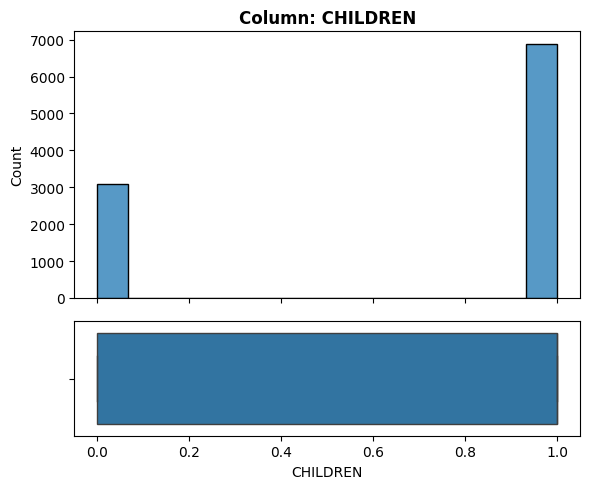

- NaN's Found: 0 (0.0%)
- Unique Values: 2
- Most common value: '1.0' occurs 6881 times (68.95%)
- Not constant or quasi-constant.


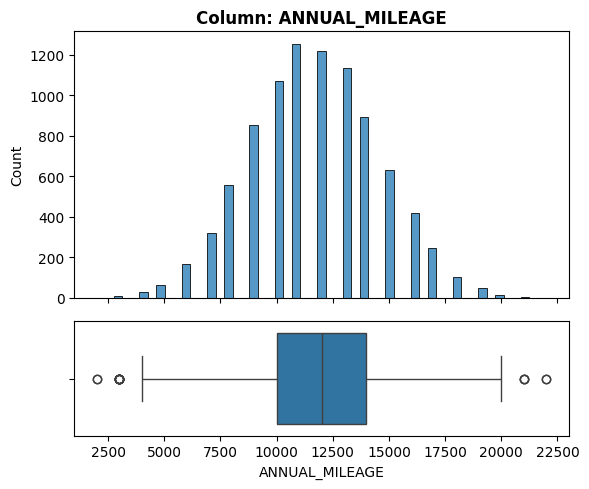

- NaN's Found: 952 (9.54%)
- Unique Values: 21
- Most common value: '11000.0' occurs 1252 times (12.55%)
- Not constant or quasi-constant.


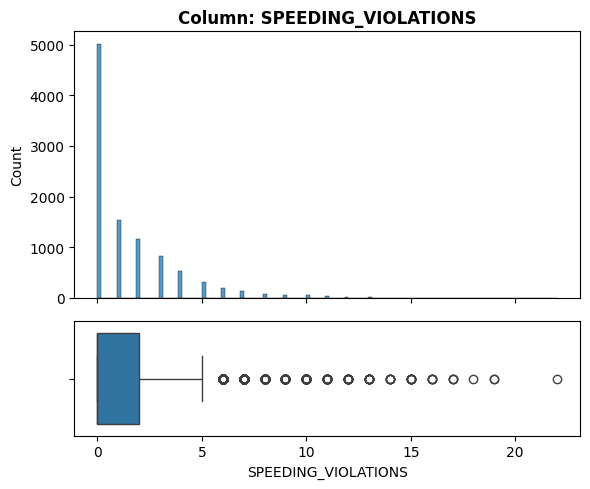

- NaN's Found: 0 (0.0%)
- Unique Values: 21
- Most common value: '0' occurs 5011 times (50.21%)
- Not constant or quasi-constant.


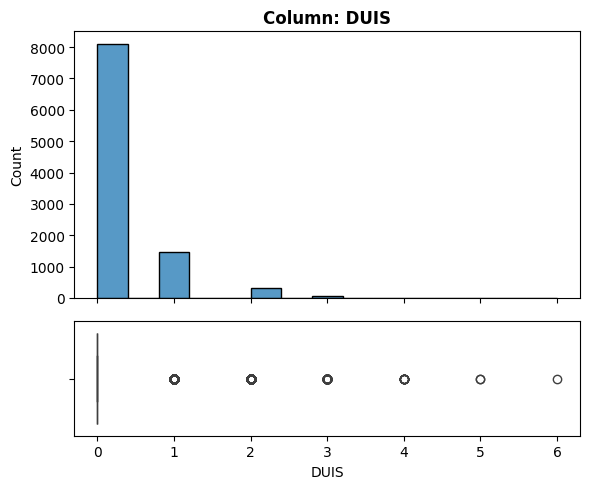

- NaN's Found: 0 (0.0%)
- Unique Values: 7
- Most common value: '0' occurs 8098 times (81.14%)
- Not constant or quasi-constant.


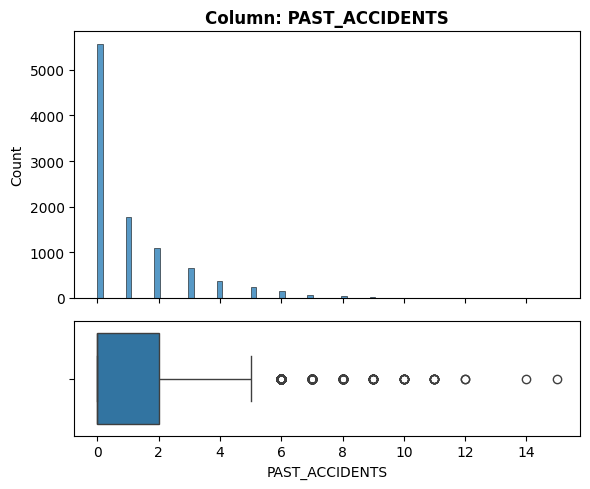

- NaN's Found: 0 (0.0%)
- Unique Values: 15
- Most common value: '0' occurs 5566 times (55.77%)
- Not constant or quasi-constant.


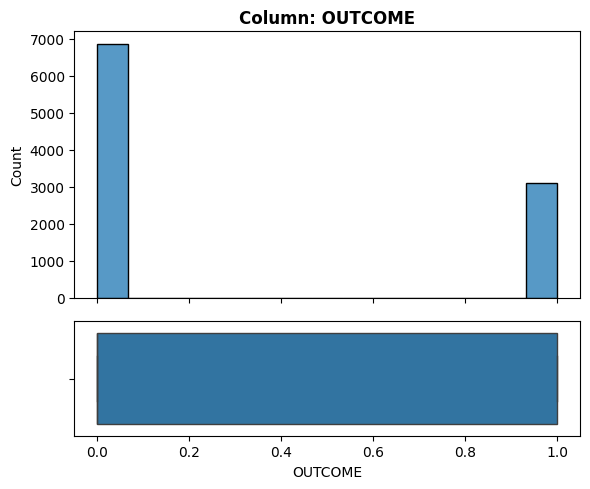

- NaN's Found: 0 (0.0%)
- Unique Values: 2
- Most common value: '0.0' occurs 6862 times (68.76%)
- Not constant or quasi-constant.


In [60]:
for col in numeric_cols:
  explore_numeric(df, col)

/tmp/ipykernel_9708/1926817873.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipykernel_9708/1926817873.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipykernel_9708/1926817873.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


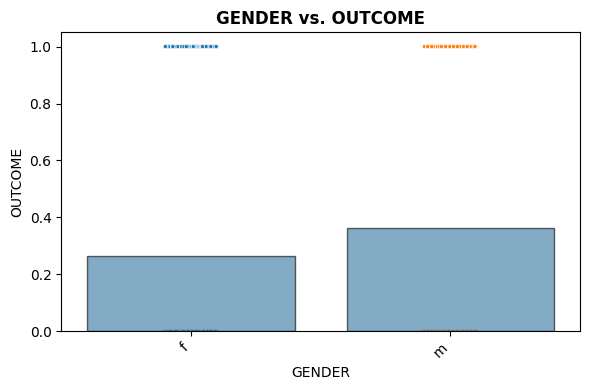

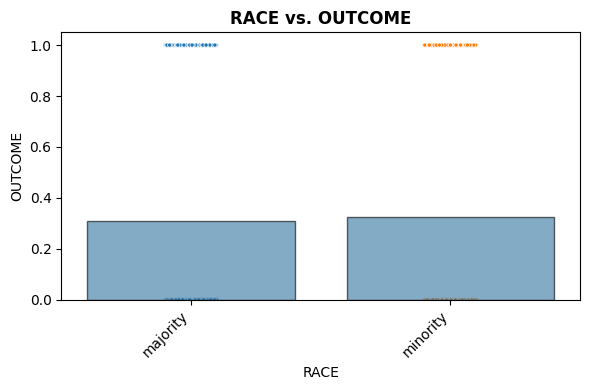

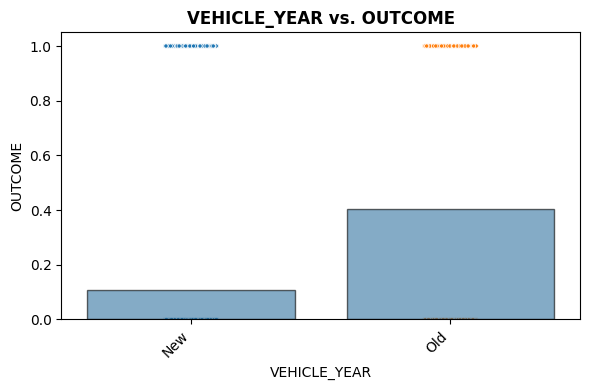

In [61]:
for col in cat_cols:
  plot_categorical_vs_target(df, col)


/tmp/ipykernel_9708/1926817873.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipykernel_9708/1926817873.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipykernel_9708/1926817873.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipykernel_9708/1926817873.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


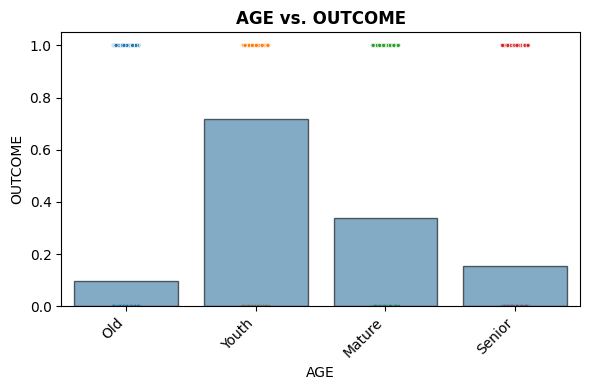

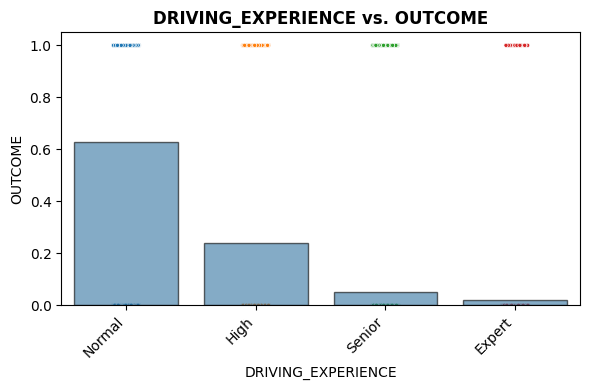

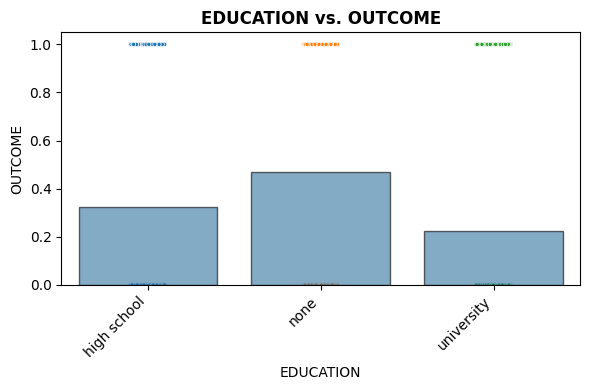

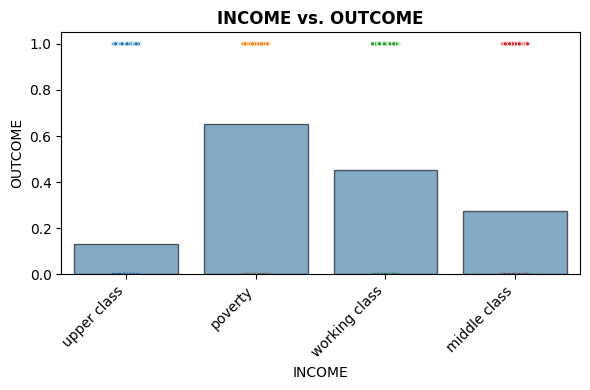

In [62]:
for col in ordinal_cols:
  plot_categorical_vs_target(df, col)

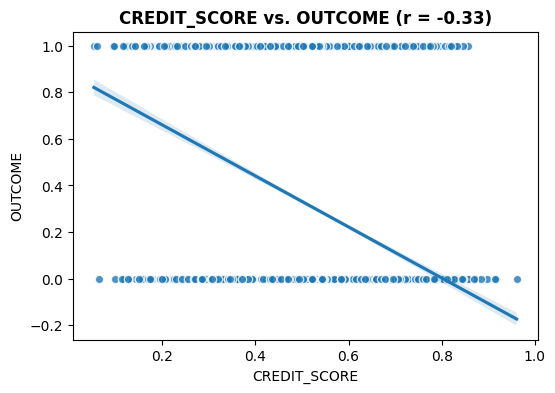

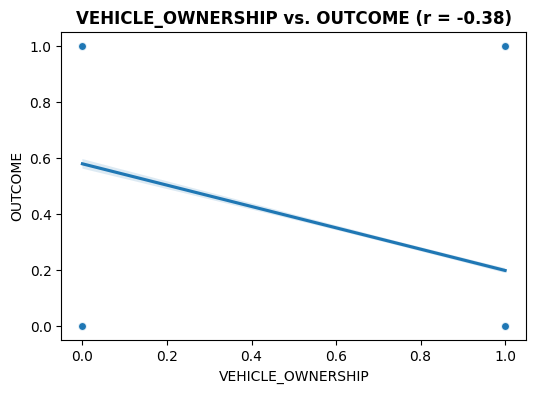

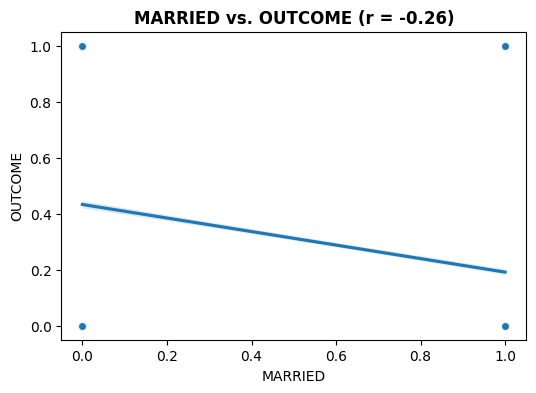

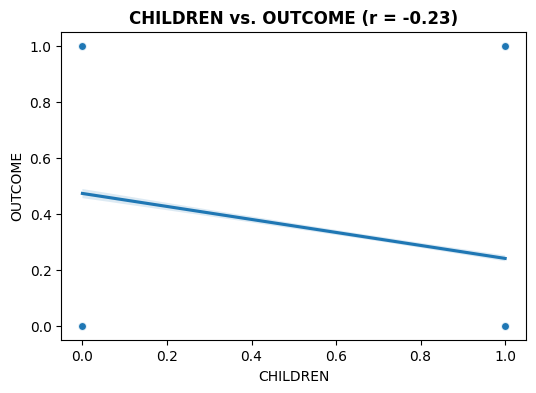

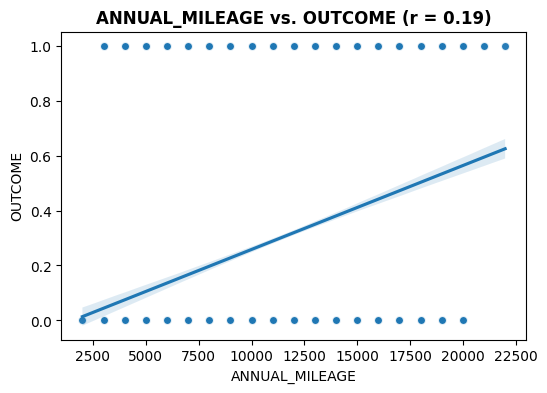

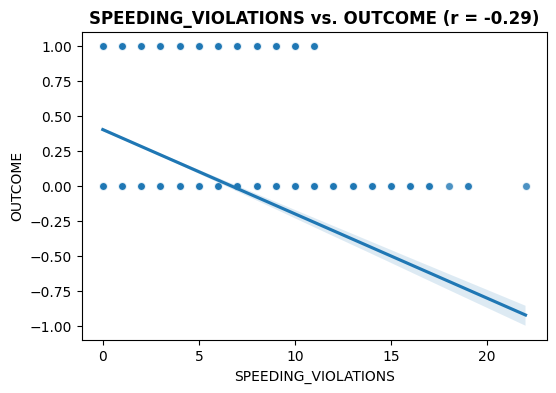

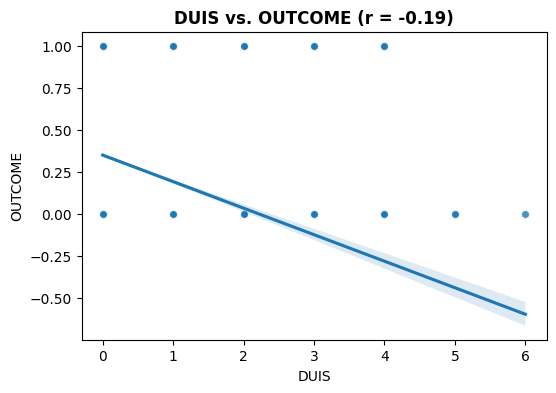

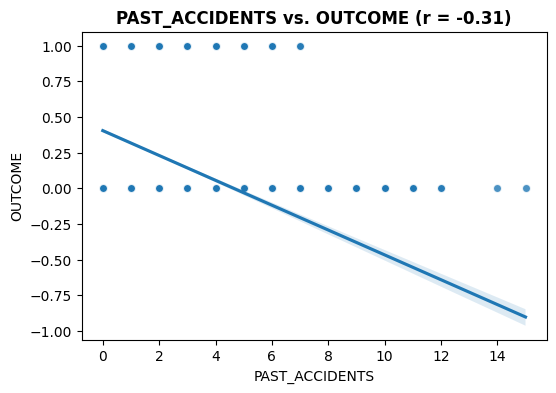

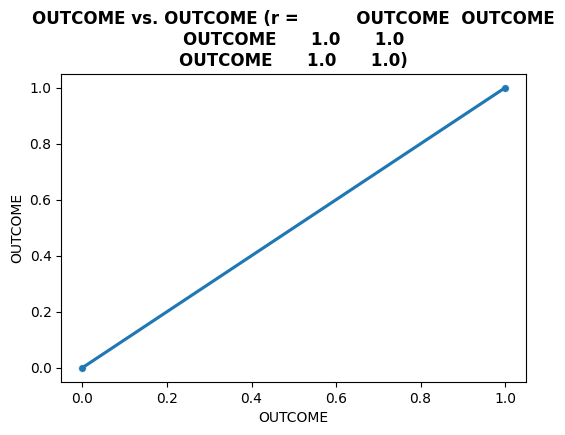

In [63]:
for col in numeric_cols:
  plot_numeric_vs_target(df, col)

Now after seeing the relationships and visualizations, we can notice that the numeric data has lots of outliers but they all fall within a normal range for values not imaginary ones.

Now Let's split the data

In [64]:
y = df['OUTCOME']
X = df.drop(columns='OUTCOME')
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)
X_train.head()

,AGE,GENDER,RACE,DRIVING_EXPERIENCE,EDUCATION,INCOME,CREDIT_SCORE,VEHICLE_OWNERSHIP,VEHICLE_YEAR,MARRIED,CHILDREN,ANNUAL_MILEAGE,SPEEDING_VIOLATIONS,DUIS,PAST_ACCIDENTS
3513,Old,f,majority,Senior,high school,upper class,0.681144,1.0,Old,0.0,1.0,13000.0,1,0,0
1219,Senior,f,majority,Senior,high school,middle class,NaN,0.0,Old,1.0,1.0,14000.0,0,0,0
7801,Mature,m,majority,High,high school,working class,NaN,0.0,Old,0.0,1.0,14000.0,0,0,2
4145,Old,f,majority,Normal,university,upper class,0.467630,1.0,New,1.0,1.0,6000.0,0,0,0
3523,Senior,m,majority,Senior,university,upper class,0.526305,1.0,Old,0.0,0.0,14000.0,5,1,0


In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9980 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   AGE                  9980 non-null   object 
 1   GENDER               9980 non-null   object 
 2   RACE                 9980 non-null   object 
 3   DRIVING_EXPERIENCE   9980 non-null   object 
 4   EDUCATION            9980 non-null   object 
 5   INCOME               9980 non-null   object 
 6   CREDIT_SCORE         9018 non-null   float64
 7   VEHICLE_OWNERSHIP    9980 non-null   float64
 8   VEHICLE_YEAR         9980 non-null   object 
 9   MARRIED              9980 non-null   float64
 10  CHILDREN             9980 non-null   float64
 11  ANNUAL_MILEAGE       9028 non-null   float64
 12  SPEEDING_VIOLATIONS  9980 non-null   int64  
 13  DUIS                 9980 non-null   int64  
 14  PAST_ACCIDENTS       9980 non-null   int64  
 15  OUTCOME              9980 non-null   float6

Now let's do the preparation and encoding.

In [65]:
numeric_cols = X_train.select_dtypes(include='number').columns
numeric_cols

Index(['CREDIT_SCORE', 'VEHICLE_OWNERSHIP', 'MARRIED', 'CHILDREN',
       'ANNUAL_MILEAGE', 'SPEEDING_VIOLATIONS', 'DUIS', 'PAST_ACCIDENTS'],
      dtype='object')

In [66]:
ordinal_cols = ['AGE', 'DRIVING_EXPERIENCE', 'EDUCATION', 'INCOME']
ordinal_cols

['AGE', 'DRIVING_EXPERIENCE', 'EDUCATION', 'INCOME']

In [67]:
cat_cols = X_train.select_dtypes(include='object').drop(columns=ordinal_cols).columns
cat_cols

Index(['GENDER', 'RACE', 'VEHICLE_YEAR'], dtype='object')

In [69]:
numeric_scaler = StandardScaler()
numeric_imputer = SimpleImputer(strategy='median')
numeric_pipe = make_pipeline(numeric_imputer, numeric_scaler)
numeric_tuple = ('numeric', numeric_pipe, numeric_cols)
numeric_tuple

('numeric',
 Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                 ('standardscaler', StandardScaler())]),
 Index(['CREDIT_SCORE', 'VEHICLE_OWNERSHIP', 'MARRIED', 'CHILDREN',
        'ANNUAL_MILEAGE', 'SPEEDING_VIOLATIONS', 'DUIS', 'PAST_ACCIDENTS'],
       dtype='object'))

In [71]:
df['AGE'].value_counts()

,count
AGE,
Mature,3061
Senior,2930
Youth,1999
Old,1990


In [72]:
df['DRIVING_EXPERIENCE'].value_counts()

,count
DRIVING_EXPERIENCE,
Normal,3513
High,3297
Senior,2118
Expert,1052


In [73]:
df['EDUCATION'].value_counts()

,count
EDUCATION,
high school,4148
university,3925
none,1907


In [74]:
df['INCOME'].value_counts()

,count
INCOME,
upper class,4334
middle class,2137
poverty,1798
working class,1711


In [75]:
ordinal_scaler = StandardScaler()
# No need for ordinal imputer.
age_categories = ['Youth', 'Mature', 'Senior', 'Old']
driving_experience_categories = ['Normal', 'High', 'Senior', 'Expert']
education_categories = ['none', 'high school', 'university']
income_categories = ['poverty', 'working class', 'middle class', 'upper class']
ordinal_encoder = OrdinalEncoder(categories=[age_categories, driving_experience_categories, education_categories, income_categories])
oridnal_pipe = make_pipeline(ordinal_encoder, ordinal_scaler)
ordinal_tuple = ('ordinal', oridnal_pipe, ordinal_cols)
ordinal_tuple

('ordinal',
 Pipeline(steps=[('ordinalencoder',
                  OrdinalEncoder(categories=[['Youth', 'Mature', 'Senior',
                                              'Old'],
                                             ['Normal', 'High', 'Senior',
                                              'Expert'],
                                             ['none', 'high school',
                                              'university'],
                                             ['poverty', 'working class',
                                              'middle class', 'upper class']])),
                 ('standardscaler', StandardScaler())]),
 ['AGE', 'DRIVING_EXPERIENCE', 'EDUCATION', 'INCOME'])

In [76]:
ohe_encoder = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)
cat_pipe = make_pipeline(ohe_encoder)
cat_tuple = ('categorical', cat_pipe, cat_cols)
cat_tuple

('categorical',
 Pipeline(steps=[('onehotencoder',
                  OneHotEncoder(drop='first', handle_unknown='ignore',
                                sparse_output=False))]),
 Index(['GENDER', 'RACE', 'VEHICLE_YEAR'], dtype='object'))

In [77]:
rf_classifier = RandomForestClassifier(random_state=42)
rf_classifier_pipe = make_pipeline(ColumnTransformer([numeric_tuple, ordinal_tuple, cat_tuple], verbose_feature_names_out=False), rf_classifier)
rf_classifier_pipe

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  Index(['CREDIT_SCORE', 'VEHICLE_OWNERSHIP', 'MARRIED', 'CHILDREN',
       'ANNUAL_MILEAGE', 'SPEEDING_VIOLATIONS', 'DUIS', 'PAST_ACCIDENTS'],
      dtype='object')),
                                                 ('ordinal',
                                                  Pipeline(s...
                                                                   StandardScaler())]),
                                                  ['AGE', 'DRIVING_EXPERIENCE',
                                                   'EDUCATION', 'INCOME']),
                                                 ('categorical',
                                                  Pipeline(steps=[('onehotencoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['GENDER', 'RACE', 'VEHICLE_YEAR'], dtype='object'))],
                                   verbose_feature_names_out=False)),
                ('randomforestclassifier',
                 RandomForestClassifier(random_state=42))])

In [78]:
rf_classifier_pipe.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  Index(['CREDIT_SCORE', 'VEHICLE_OWNERSHIP', 'MARRIED', 'CHILDREN',
       'ANNUAL_MILEAGE', 'SPEEDING_VIOLATIONS', 'DUIS', 'PAST_ACCIDENTS'],
      dtype='object')),
                                                 ('ordinal',
                                                  Pipeline(s...
                                                                   StandardScaler())]),
                                                  ['AGE', 'DRIVING_EXPERIENCE',
                                                   'EDUCATION', 'INCOME']),
                                                 ('categorical',
                                                  Pipeline(steps=[('onehotencoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['GENDER', 'RACE', 'VEHICLE_YEAR'], dtype='object'))],
                                   verbose_feature_names_out=False)),
                ('randomforestclassifier',
                 RandomForestClassifier(random_state=42))])

In [79]:
def classification_metrics(y_true, y_pred, label="",
                           output_dict=False, figsize=(8,4),
                           normalize='true', cmap='Blues',
                           colorbar=False):
  # Get the classification report
  report = classification_report(y_true, y_pred)
  ## Print header and report
  header = "-"*70
  print(header, f" Classification Metrics: {label}", header, sep='\n')
  print(report)
  ## CONFUSION MATRICES SUBPLOTS
  fig, axes = plt.subplots(ncols=2, figsize=figsize)
  # create a confusion matrix  of raw counts
  ConfusionMatrixDisplay.from_predictions(y_true, y_pred,
                normalize=None, cmap='gist_gray', colorbar=colorbar,
                ax = axes[0],);
  axes[0].set_title("Raw Counts")
  # create a confusion matrix with the test data
  ConfusionMatrixDisplay.from_predictions(y_true, y_pred,
                normalize=normalize, cmap=cmap, colorbar=colorbar,
                ax = axes[1]);
  axes[1].set_title("Normalized Confusion Matrix")
  # Adjust layout and show figure
  fig.tight_layout()
  plt.show()
  # Return dictionary of classification_report
  if output_dict==True:
    report_dict = classification_report(y_true, y_pred, output_dict=True)
    return report_dict



def evaluate_classification(model, X_train, y_train, X_test, y_test,
                         figsize=(6,4), normalize='true', output_dict = False,
                            cmap_train='Blues', cmap_test="Reds",colorbar=False):
  # Get predictions for training data
  y_train_pred = model.predict(X_train)
  # Call the helper function to obtain regression metrics for training data
  results_train = classification_metrics(y_train, y_train_pred, #verbose = verbose,
                                     output_dict=True, figsize=figsize,
                                         colorbar=colorbar, cmap=cmap_train,
                                     label='Training Data')
  print()
  # Get predictions for test data
  y_test_pred = model.predict(X_test)
  # Call the helper function to obtain regression metrics for test data
  results_test = classification_metrics(y_test, y_test_pred, #verbose = verbose,
                                  output_dict=True,figsize=figsize,
                                         colorbar=colorbar, cmap=cmap_test,
                                    label='Test Data' )
  if output_dict == True:
    # Store results in a dataframe if ouput_frame is True
    results_dict = {'train':results_train,
                    'test': results_test}
    return results_dict

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      5184
         1.0       1.00      1.00      1.00      2301

    accuracy                           1.00      7485
   macro avg       1.00      1.00      1.00      7485
weighted avg       1.00      1.00      1.00      7485



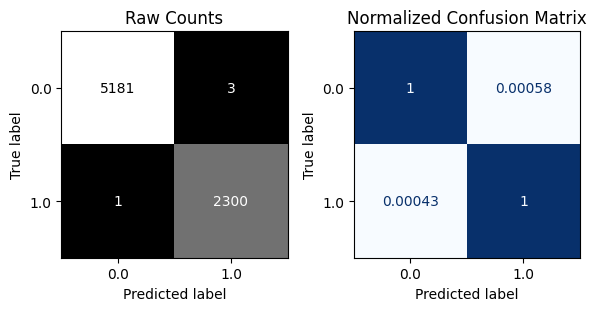


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

         0.0       0.84      0.89      0.87      1678
         1.0       0.75      0.66      0.70       817

    accuracy                           0.82      2495
   macro avg       0.80      0.77      0.78      2495
weighted avg       0.81      0.82      0.81      2495



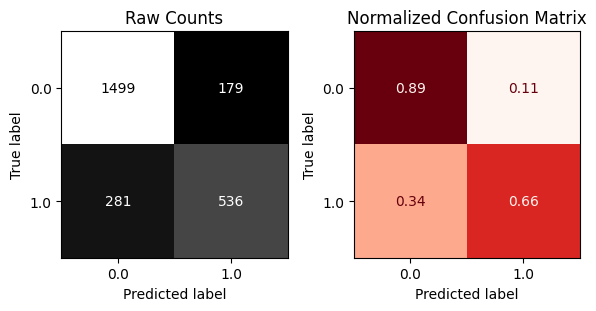

In [80]:
evaluate_classification(rf_classifier_pipe, X_train, y_train, X_test, y_test)

Let's move to extracting and visualizaing the most important 10 features

In [81]:
from sklearn.inspection import permutation_importance

In [88]:
r = permutation_importance(rf_classifier_pipe, X_test, y_test,n_repeats =5, random_state = 42)
r.keys()

dict_keys(['importances_mean', 'importances_std', 'importances'])

In [89]:
# now let's see the feature importance according to the permutation importance
permutation_importances = pd.Series(r['importances_mean'], index = X_test.columns, name='premutation importances')
permutation_importances = permutation_importances.sort_values(ascending=False)
permutation_importances

,premutation importances
DRIVING_EXPERIENCE,0.054589
VEHICLE_OWNERSHIP,0.041202
VEHICLE_YEAR,0.035671
GENDER,0.013146
PAST_ACCIDENTS,0.009780
SPEEDING_VIOLATIONS,0.000080
DUIS,-0.000080
MARRIED,-0.000401
CHILDREN,-0.002084
RACE,-0.002565


In [91]:
def plot_importance(importances, top_n=None,  figsize=(8,6)):
    # sorting with asc=false for correct order of bars
    if top_n==None:
        ## sort all features and set title
        plot_vals = importances.sort_values()
        title = "All Features - Ranked by Importance"
    else:
        ## sort features and keep top_n and set title
        plot_vals = importances.sort_values().tail(top_n)
        title = f"Top {top_n} Most Important Features"
    ## plotting top N importances
    ax = plot_vals.plot(kind='barh', figsize=figsize)
    ax.set(xlabel='Importance',
            ylabel='Feature Names',
            title=title)
    ## return ax in case want to continue to update/modify figure
    return ax

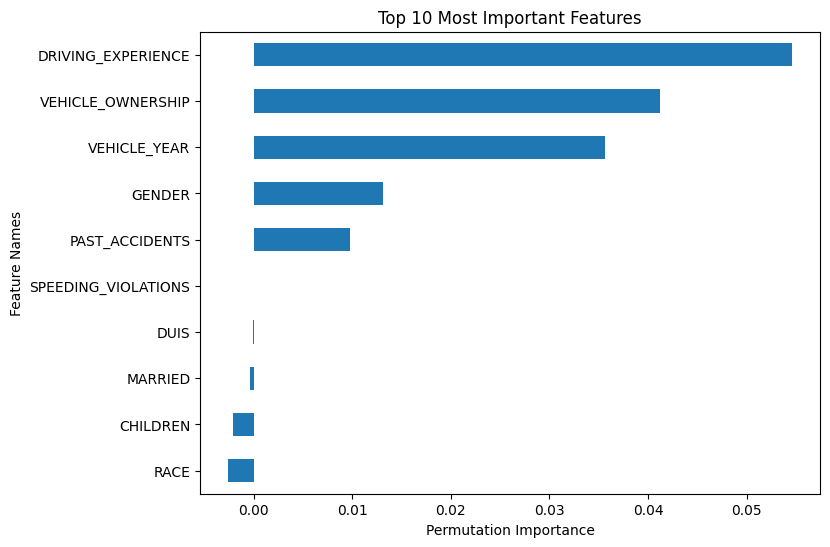

In [92]:
ax = plot_importance(permutation_importances,top_n=10)
ax.set(xlabel='Permutation Importance');

These 10 features make sence but the fact that speeding violations has no affect on the outcome is interesting, this could be due to the greed of insurance company that they would care about the possibilities of the accidents more than the commitment to the law. On the other hand, I though DUIS, Married, children, and race would have further importance as they could lead to damaging the car and affecting the outcome, but it turned out not, so that is interesting.
but since they have negative importance then that seems like they affected in negative like the married had less chance of receiving insurance and same goes for children and DUIS but Race is really interesting, I thought it was supposed to have no relation.

The top two important features are: <br/>
1- DRIVING_EXPERIENCE <br/>
2- VEHICLE_OWNERSHIP


let's use the original data frame and plot their relationship with the outcome

/tmp/ipykernel_9708/1926817873.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'DRIVING_EXPERIENCE vs. OUTCOME'}, xlabel='DRIVING_EXPERIENCE', ylabel='OUTCOME'>)

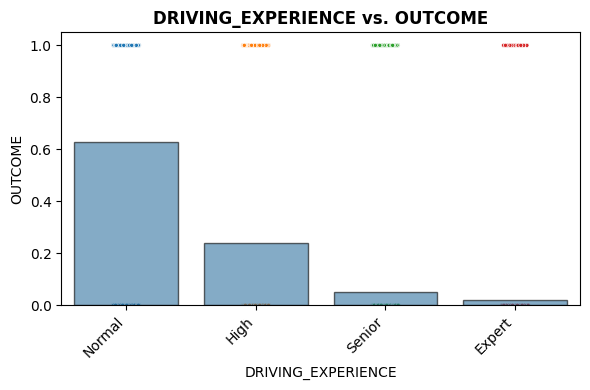

In [93]:
# first Driving experience against the target:
plot_categorical_vs_target(df, 'DRIVING_EXPERIENCE')


Something weird is happening here, the driving experience seems to be not increasing the average of receiving an insurance.

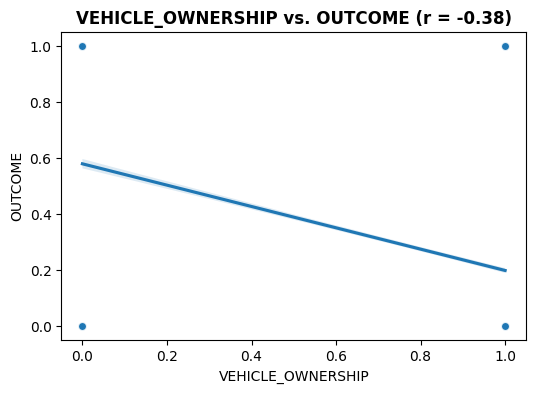

(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'VEHICLE_OWNERSHIP vs. OUTCOME (r = -0.38)'}, xlabel='VEHICLE_OWNERSHIP', ylabel='OUTCOME'>)

In [94]:
# now Let's plot the vehical ownership
plot_numeric_vs_target(df, 'VEHICLE_OWNERSHIP')

Also we can notice here something weird, that the more the car is owned then the less insurance possibility there is.

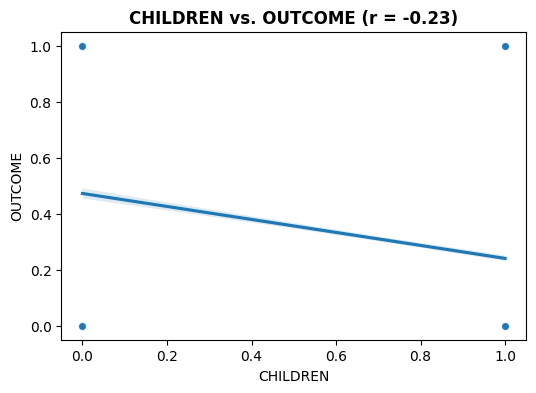

(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'CHILDREN vs. OUTCOME (r = -0.23)'}, xlabel='CHILDREN', ylabel='OUTCOME'>)

In [96]:
plot_numeric_vs_target(df, 'CHILDREN')

/tmp/ipykernel_9708/1926817873.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'AGE vs. OUTCOME'}, xlabel='AGE', ylabel='OUTCOME'>)

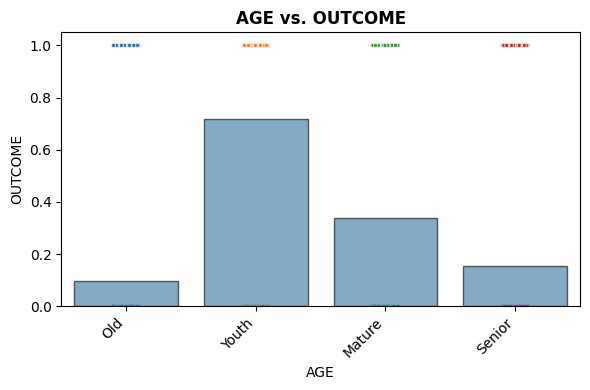

In [97]:
plot_categorical_vs_target(df, 'AGE')